              Unnamed: 1    Unnamed: 2    Unnamed: 3    Unnamed: 4  \
Date                                                                 
2023-01-01  16625.080078  16630.439453  16521.234375  16547.914062   
2023-01-02  16688.470703  16759.343750  16572.228516  16625.509766   
2023-01-03  16679.857422  16760.447266  16622.371094  16688.847656   
2023-01-04  16863.238281  16964.585938  16667.763672  16680.205078   
2023-01-05  16836.736328  16884.021484  16790.283203  16863.472656   

             Unnamed: 5  
Date                     
2023-01-01   9244361700  
2023-01-02  12097775227  
2023-01-03  13903079207  
2023-01-04  18421743322  
2023-01-05  13692758566  
=== Data Overview ===
                    Open          High           Low         Close  \
Date                                                                 
2023-01-01  16625.080078  16630.439453  16521.234375  16547.914062   
2023-01-02  16688.470703  16759.343750  16572.228516  16625.509766   
2023-01-03  16679.857422 

/tmp/ipython-input-2970700030.py:155: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = data.resample('M').agg({


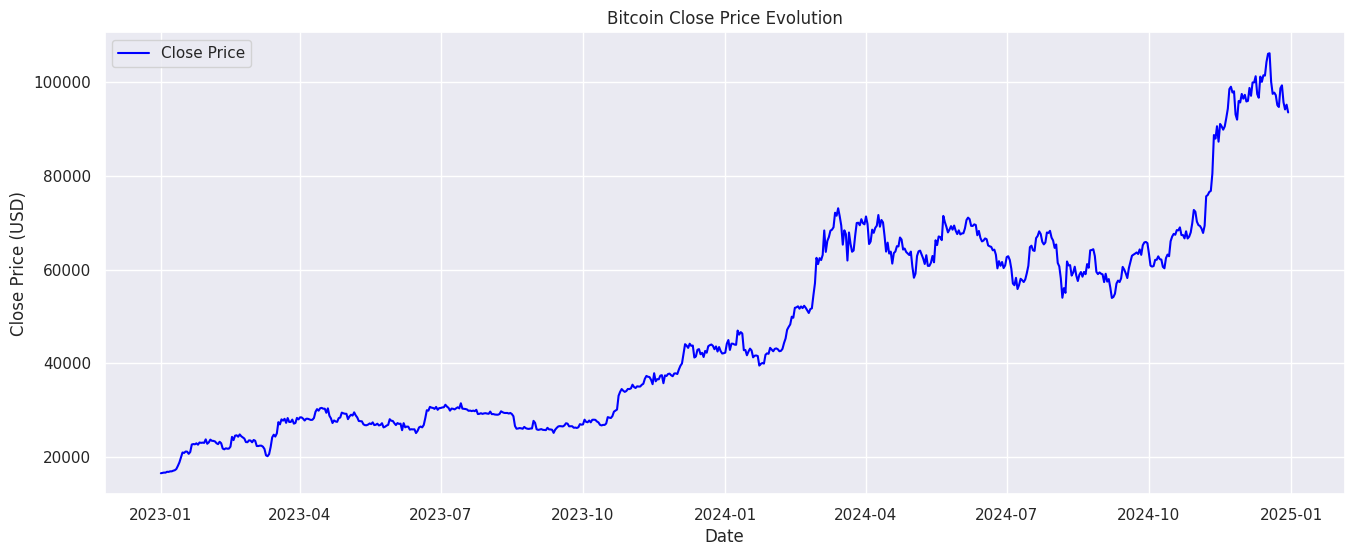

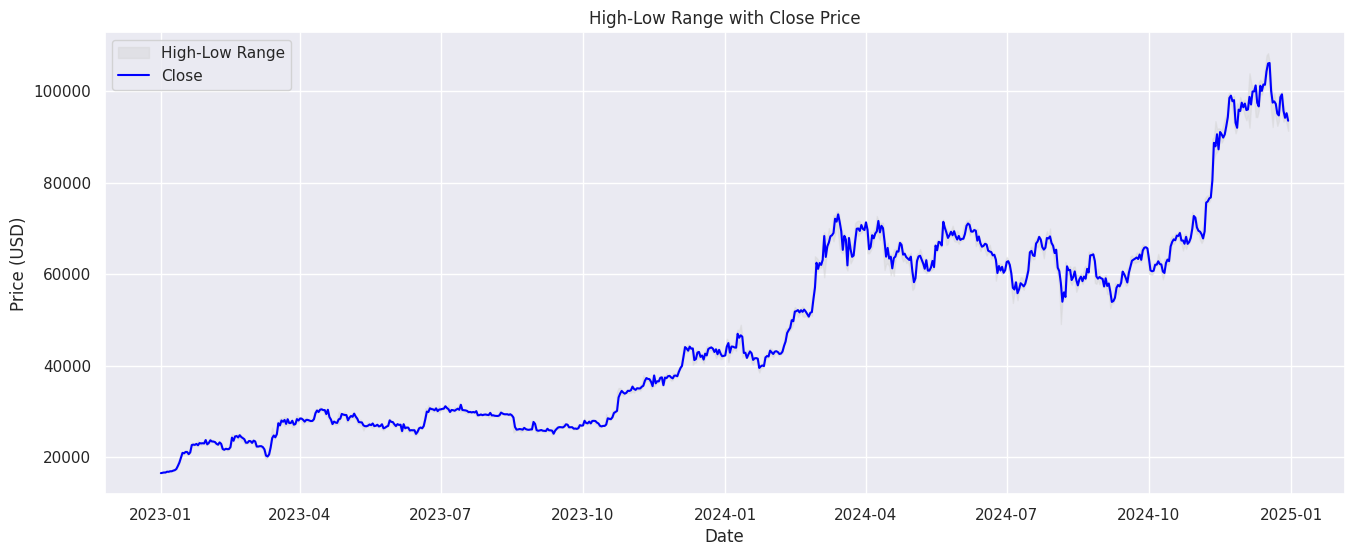

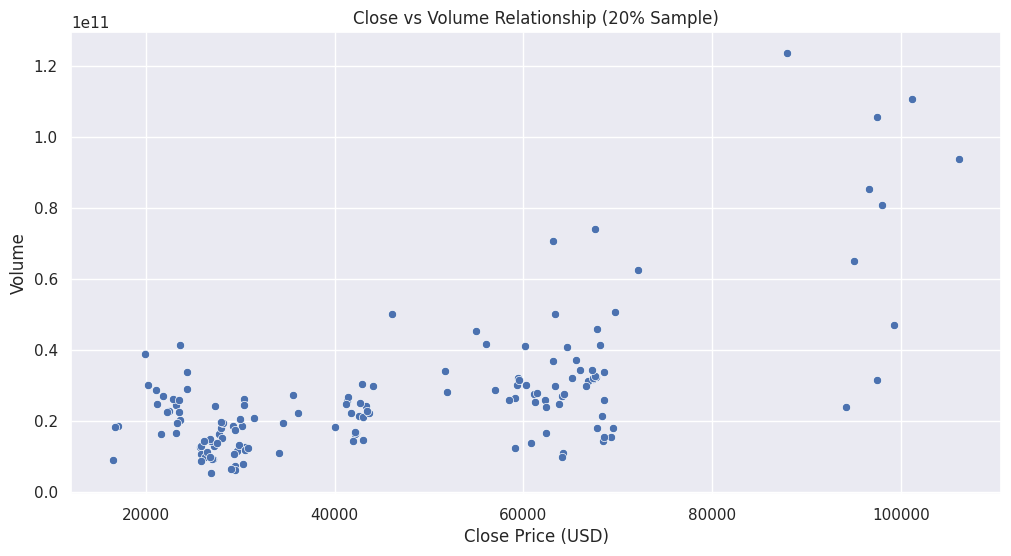

/tmp/ipython-input-2970700030.py:220: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x='Filter', y='Average Close', palette='viridis')


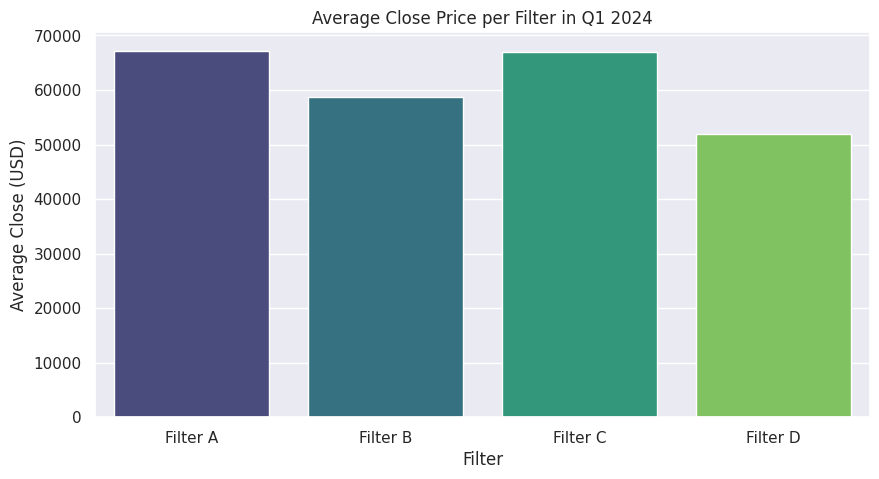

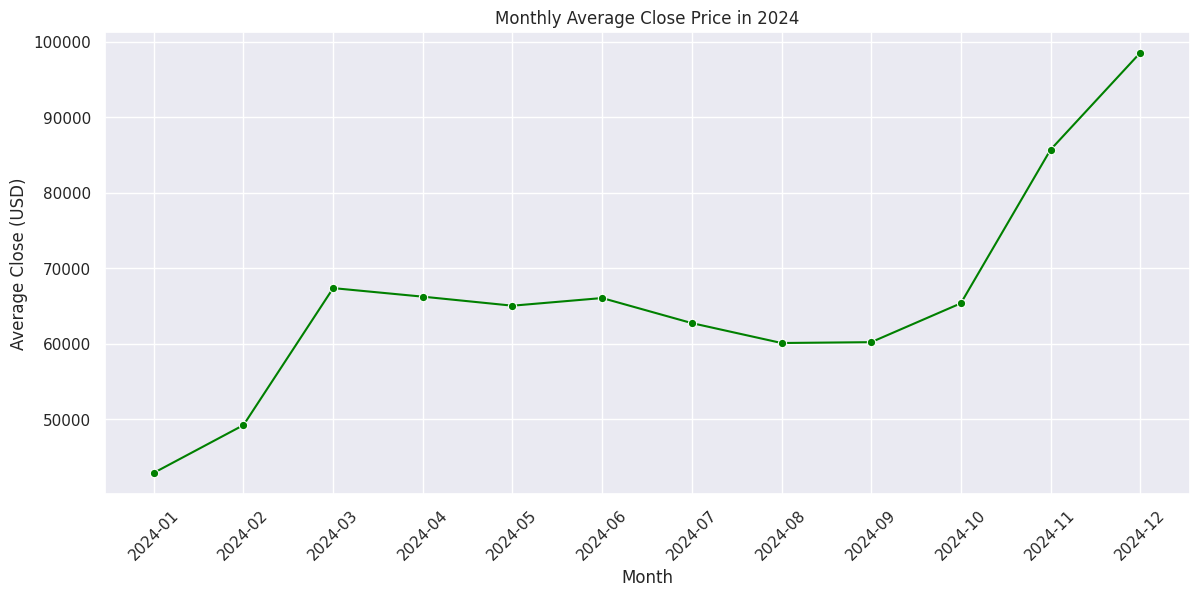

/tmp/ipython-input-2970700030.py:236: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_summary_df, x='Month', y='Total Volume', palette='coolwarm')


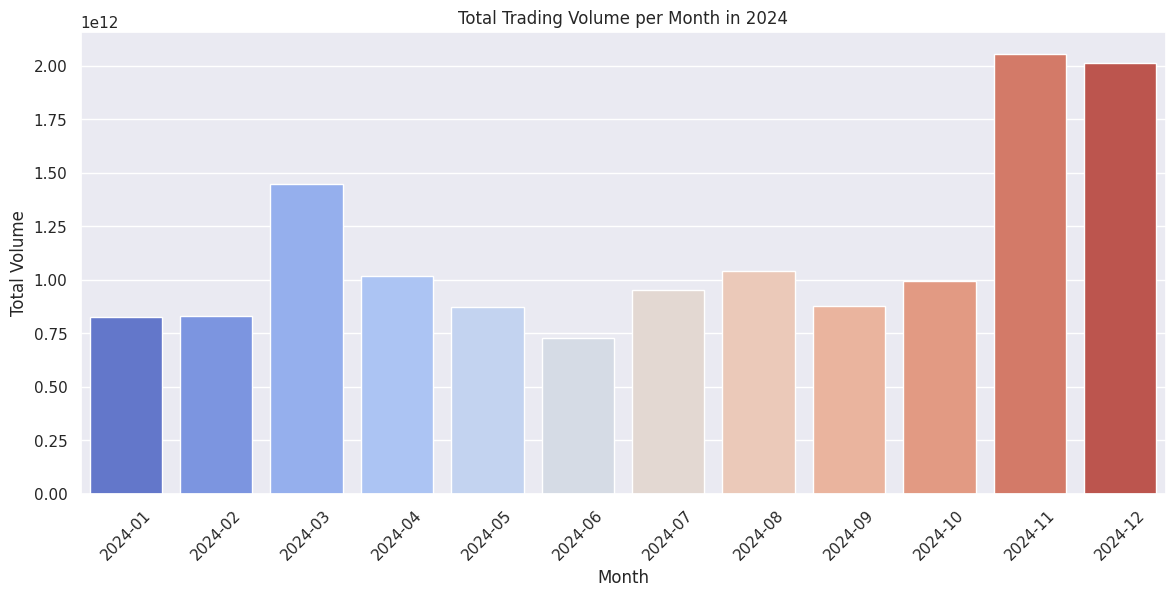

In [14]:
# %%
import pandas as pd

# Part 1: Load CSV & Preprocessing

data = pd.read_csv('/content/bitcoin_price.csv',
                   skiprows=[0,1],
                   parse_dates=['Date'],
                   index_col='Date')

print(data.head())

data.columns = ['Open', 'High', 'Low', 'Close', 'Volume']


for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

print("=== Data Overview ===")
print(data.head())
print(data.info())
print("\nDate Range:", data.index.min(), "→", data.index.max())
print("Total Trading Days:", data.shape[0])
print("Min Close:", data['Close'].min())
print("Max Close:", data['Close'].max())
print("Mean Close:", round(data['Close'].mean(), 2))

#  Part 2: Date-Based Filtering
print("\n=== Part 2: Date-Based Filtering ===")

# الربع الأول من 2024
q1_2024 = data.loc['2024-01-01':'2024-03-31']
print("\nQ1 2024 Data:")
print(q1_2024.head())

# بيانات يوم محدد
valentine_day = data.loc['2024-02-14']
print("\nBitcoin on 14 Feb 2024:")
print(valentine_day)

# آخر أسبوع من 2023
last_week_2023 = data.loc['2023-12-24':'2023-12-31']
print("\nLast Week of 2023:")
print(last_week_2023)

# كل بيانات سنة 2024
data_2024 = data[data.index.year == 2024]
print("\nAll Data for 2024:")
print(data_2024.head())

# بيانات يوم 14 فبراير 2024
try:
    valentine_day = data.loc['2024-02-14']
    print("\nBitcoin on 14 Feb 2024:")
    print(valentine_day)
except KeyError:
    print("\nNo trading data for 14 Feb 2024 (market closed).")
print("===================*50")

#Part 3: Boolean Indexing
print("\n=== Part 3: Boolean Indexing ===")

# أيام Close > 60K
high_close_days = data[data['Close'] > 60000]
print("\nHigh Close Days (Close > $60,000):")
print(high_close_days.head())
print("Count:", len(high_close_days))
print("Average Close:", high_close_days['Close'].mean())

# أيام حجم التداول > 30B
high_volume_days = data[data['Volume'] > 30000000000]
print("\nHigh Volume Days (Volume > 30B):")
print(high_volume_days[['Close', 'Volume']].head())
print("Count:", len(high_volume_days))

# AND
and_condition_days = data[(data['Close'] > 50000) & (data['Volume'] > 25000000000)]
print("\nDays with Close > 50K AND Volume > 25B:")
print(and_condition_days.head())
print("Count:", len(and_condition_days))

# OR
or_condition_days = data[(data['Close'] > 65000) | (data['Volume'] > 35000000000)]
print("\nDays with Close > 65K OR Volume > 35B:")
print(or_condition_days.head())
print("Count:", len(or_condition_days))

#  Part 4:
print("\n=== Part 4: Using .query() Method ===")

query_and_days = data.query('Close > 50000 and Volume > 25000000000')
print("\nQuery - Close > 50K AND Volume > 25B:")
print(query_and_days.head())
print("Count:", len(query_and_days))

between_days = data.query('Close >= 40000 and Close <= 50000')
print("\nPrice Between $40K and $50K:")
print(between_days.head())

# Close rounded for exact prices
data['Close_Rounded'] = data['Close'].round(-3)
exact_prices = [50000, 55000, 60000, 65000]
in_days = data.query('Close_Rounded in @exact_prices')
print("\nExact Close Prices (50K,55K,60K,65K):")
print(in_days.head())
print("Count:", len(in_days))

# NOT between 45K and 55K
not_days = data.query('not Close.between(45000, 55000)')
print("\nDays with Close NOT between 45K and 55K:")
print(not_days.head())
print("Count:", len(not_days))

# ================= Part 5: Complex Multi-Condition Filters =================
print("\n=== Part 5: Complex Multi-Condition Filters ===")

# Bull Market Days
bull_market = data.query('Close > Open and Close > 55000 and Volume > 20000000000')
print("\n=== Bull Market Days ===")
print(bull_market.head())
print("Count:", len(bull_market))
print("Average Daily Gain:", (bull_market['Close'] - bull_market['Open']).mean())
print("Total Volume:", bull_market['Volume'].sum())

# Volatile Days
volatile_days = data.query('(High - Low) > 3000 and Volume > 25000000000')
print("\n=== Volatile Days ===")
print(volatile_days.head())
print("Count:", len(volatile_days))

# Q1 2024 Filters Summary
filters = {
    'Filter A': 'Close > 60000',
    'Filter B': 'Volume > 30000000000',
    'Filter C': 'Close > 55000 and Volume > 25000000000',
    'Filter D': 'Close < 45000 or Volume > 35000000000'
}

summary = []
for name, condition in filters.items():
    df_filtered = data.loc['2024-01':'2024-03'].query(condition)
    summary.append({
        'Filter': name,
        'Number of Days': len(df_filtered),
        'Average Close': df_filtered['Close'].mean(),
        'Average Volume': df_filtered['Volume'].mean()
    })

summary_df = pd.DataFrame(summary)
print("\n=== Q1 2024 Filters Summary ===")
print(summary_df)

#Part 6: Monthly Analysis
print("\n=== Monthly Analysis ===")
monthly_data = data.resample('M').agg({
    'Close': ['min','max','mean'],
    'Volume': 'sum'
})
monthly_data.columns = ['Min Close','Max Close','Mean Close','Total Volume']
print(monthly_data)

print("\n=== 2024 Monthly Performance ===")
months = [f'2024-{str(i).zfill(2)}' for i in range(1, 13)]
monthly_summary = []

for month in months:
    df_month = data.loc[month]
    if not df_month.empty:
        start_price = df_month['Close'].iloc[0]
        end_price = df_month['Close'].iloc[-1]
        monthly_return = ((end_price - start_price) / start_price) * 100
        monthly_summary.append({
            'Month': month,
            'Trading Days': len(df_month),
            'Average Close': df_month['Close'].mean(),
            'Monthly Return %': round(monthly_return, 2),
            'Highest Price': df_month['High'].max(),
            'Total Volume': df_month['Volume'].sum()
        })

monthly_summary_df = pd.DataFrame(monthly_summary)
print(monthly_summary_df)

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (14,6)
sns.set()

# 1️⃣ Close Price Evolution
plt.figure(figsize=(16,6))
plt.plot(data['Close'], label='Close Price', color='blue')
plt.title('Bitcoin Close Price Evolution')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.show()

# 2️⃣ High-Low Range with Close
plt.figure(figsize=(16,6))
plt.fill_between(data.index, data['Low'], data['High'], color='lightgray', alpha=0.4, label='High-Low Range')
plt.plot(data['Close'], label='Close', color='blue')
plt.title('High-Low Range with Close Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

# 3️⃣ Scatter Plot: Close vs Volume (sample to show relationship)
plt.figure(figsize=(12,6))
sns.scatterplot(data=data.sample(frac=0.2, random_state=1), x='Close', y='Volume')
plt.title('Close vs Volume Relationship (20% Sample)')
plt.xlabel('Close Price (USD)')
plt.ylabel('Volume')
plt.show()

# 4️⃣ Average Close per Filter Q1 2024 (Bar Plot)
plt.figure(figsize=(10,5))
sns.barplot(data=summary_df, x='Filter', y='Average Close', palette='viridis')
plt.title('Average Close Price per Filter in Q1 2024')
plt.ylabel('Average Close (USD)')
plt.show()

# 5️⃣ Monthly Average Close in 2024
plt.figure(figsize=(14,6))
sns.lineplot(data=monthly_summary_df, x='Month', y='Average Close', marker='o', color='green')
plt.title('Monthly Average Close Price in 2024')
plt.xlabel('Month')
plt.ylabel('Average Close (USD)')
plt.xticks(rotation=45)
plt.show()

# 6️⃣ Monthly Total Volume in 2024 (Bar Plot)
plt.figure(figsize=(14,6))
sns.barplot(data=monthly_summary_df, x='Month', y='Total Volume', palette='coolwarm')
plt.title('Total Trading Volume per Month in 2024')
plt.xlabel('Month')
plt.ylabel('Total Volume')
plt.xticks(rotation=45)
plt.show()

# %%


In [ ]:
from google.colab import drive
drive.mount('/content/drive')